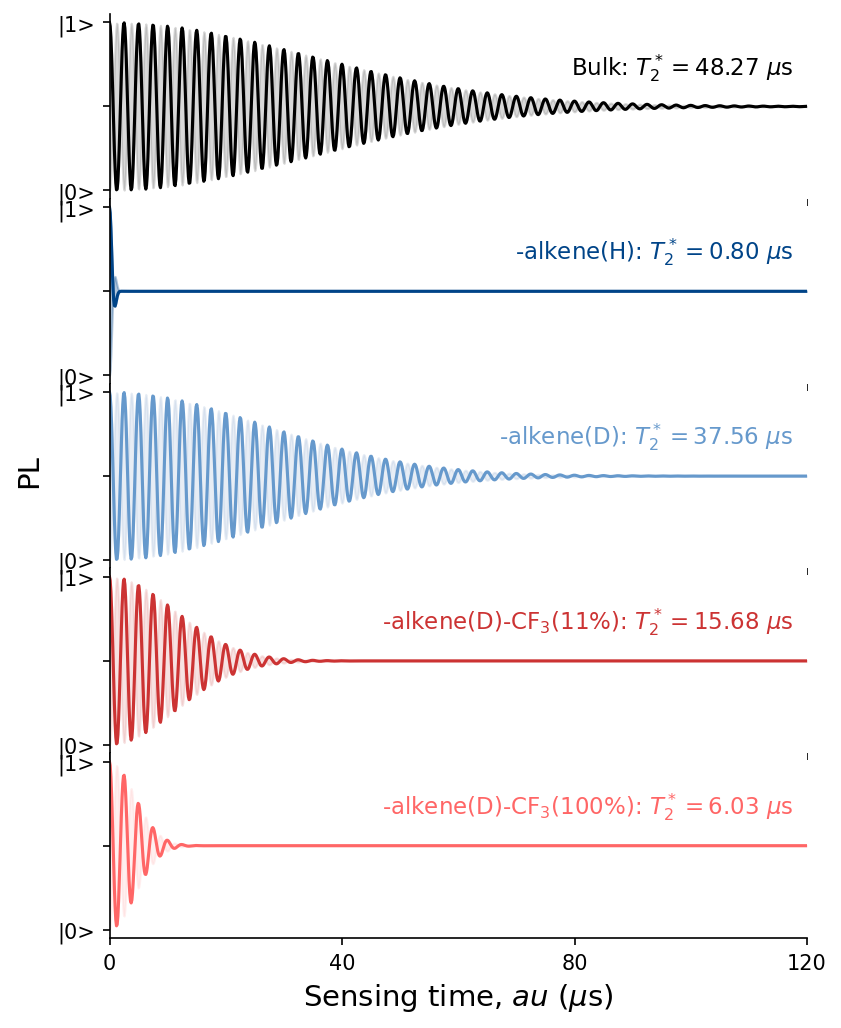

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
t = np.linspace(0, 120, 1000) # Microseconds

def rabi_decay(t, T2, freq=0.5):
    envelope = np.exp(-(t / T2)**2) # Gaussian decay typically for T2*
    oscillation = np.cos(2 * np.pi * freq * t)
    return envelope * oscillation

# Parameters from image
# 1. Bulk (Black)
y1 = rabi_decay(t, T2=48.27, freq=0.4)
# 2. -alkene(H) (Blue, fast decay)
y2 = rabi_decay(t, T2=0.80, freq=0.4)
# 3. -alkene(D) (Light Blue)
y3 = rabi_decay(t, T2=37.56, freq=0.4)
# 4. -alkene(D)-CF3(11%) (Red)
y4 = rabi_decay(t, T2=15.68, freq=0.4)
# 5. -alkene(D)-CF3(100%) (Light Red)
y5 = rabi_decay(t, T2=6.03, freq=0.4)

datasets = [
    (y1, 'black', 'gray', r'Bulk: $T_2^* = 48.27$ $\mu$s'),
    (y2, '#004488', '#004488', r'-alkene(H): $T_2^* = 0.80$ $\mu$s'),
    (y3, '#6699CC', '#B0C4DE', r'-alkene(D): $T_2^* = 37.56$ $\mu$s'),
    (y4, '#CC3333', '#E6A0A0', r'-alkene(D)-CF$_3$(11%): $T_2^* = 15.68$ $\mu$s'),
    (y5, '#FF6666', '#FFCCCC', r'-alkene(D)-CF$_3$(100%): $T_2^* = 6.03$ $\mu$s')
]

# --- Plotting ---
fig, axes = plt.subplots(5, 1, figsize=(6, 8), dpi=150, sharex=True, sharey=True)
plt.subplots_adjust(hspace=0)

for i, (ax, (y, col, fill_col, lbl)) in enumerate(zip(axes, datasets)):
    # Calculate envelope for filling
    env = np.exp(-(t / float(lbl.split('=')[1].split('$')[0].strip()))**2)
    # Or just use positive/negative max of signal for visual

    ax.plot(t, y, color=col, linewidth=1.5)
    ax.fill_between(t, y, -y, color=fill_col, alpha=0.3)

    # Label
    ax.text(0.98, 0.8, lbl, transform=ax.transAxes, ha='right', va='top', fontsize=11, color=col)

    # Y Ticks
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(['|0>', '', '|1>'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    if i == 4:
        ax.spines['bottom'].set_visible(True)

# X Label
axes[-1].set_xlabel(r'Sensing time, $	au$ ($\mu$s)', fontsize=14)
axes[-1].set_xticks([0, 40, 80, 120])
axes[-1].set_xlim(0, 120)

# Common Y Label
fig.text(0.02, 0.5, 'PL', va='center', rotation='vertical', fontsize=14)

plt.show()
